Slope (m): [0.6]
Intercept (b): [2.2]
Predict Value: [[4.6]]


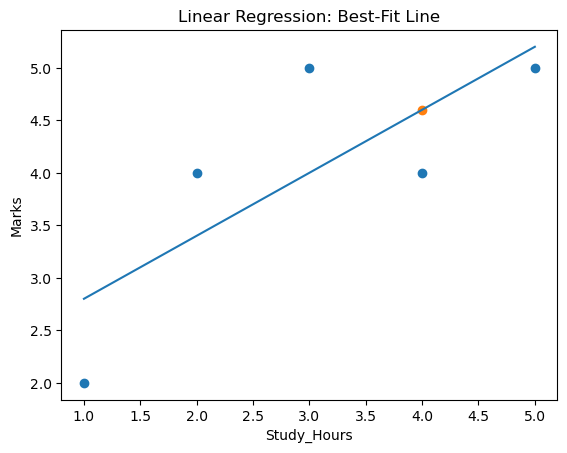

MSE: 0.47999999999999987
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  72 non-null     int64
 1   Attendance   72 non-null     int64
 2   Sleep_Hours  72 non-null     int64
 3   Marks        72 non-null     int64
dtypes: int64(4)
memory usage: 2.4 KB
None
       Study_Hours  Attendance  Sleep_Hours      Marks
count    72.000000   72.000000    72.000000  72.000000
mean      6.000000   73.625000     6.222222  64.194444
std       2.600108    7.305097     0.922676   8.935826
min       2.000000   60.000000     5.000000  48.000000
25%       4.000000   68.000000     6.000000  57.000000
50%       6.000000   73.500000     6.000000  64.000000
75%       8.000000   79.000000     7.000000  71.000000
max      10.000000   96.000000     8.000000  84.000000
Model Intercept: -8.590968888225518
Model Coefficients: [0.67373373 0.81037905 1.46344888]


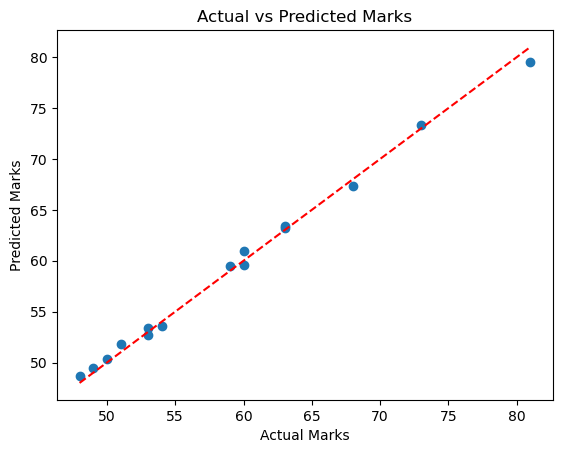

Mean Squared Error: 0.4103783937973659


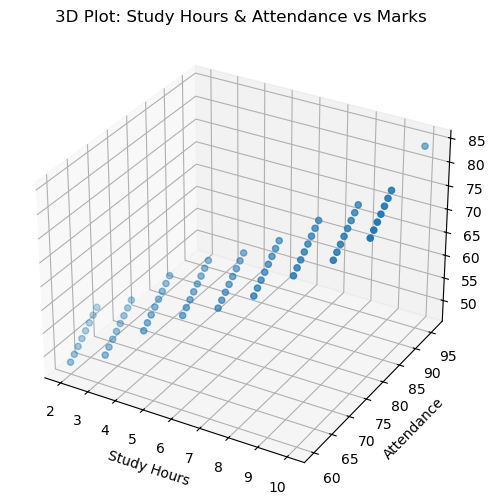

In [2]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from mpl_toolkits.mplot3d import Axes3D

df = pd.DataFrame({
    "Study_Hours":[1,2,3,4,5],
    "Marks":[2,4,5,4,5]
})

X = df[["Study_Hours"]]
y = df[["Marks"]]

model = LinearRegression()
model.fit(X,y)

X_line = pd.DataFrame({
    "Study_Hours": np.linspace(X["Study_Hours"].min(), X["Study_Hours"].max(), 100)
})

y_line = model.predict(X_line)

print("Slope (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

X_new = pd.DataFrame({"Study_Hours":[4.0]})
y_new = model.predict(X_new)
print("Predict Value:", y_new)

plt.figure()
plt.scatter(X,y)
plt.plot(X_line,y_line)
plt.scatter(X_new,y_new)
plt.xlabel("Study_Hours")
plt.ylabel("Marks")
plt.title("Linear Regression: Best-Fit Line")
plt.show()

y_pred = model.predict(X)
mse = mean_squared_error(y,y_pred)
print("MSE:", mse)

df = pd.read_csv(r"C:\Users\NARASIMHA\OneDrive\Desktop\MLR_Study_marks.csv")

print(df.info())
print(df.describe())

X = df[["Study_Hours","Attendance","Sleep_Hours"]]
y = df["Marks"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

print("Model Intercept:", model.intercept_)
print("Model Coefficients:", model.coef_)

y_pred = model.predict(X_test)

plt.scatter(y_test,y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.show()

mse = mean_squared_error(y_test,y_pred)
print("Mean Squared Error:", mse)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df["Study_Hours"], df["Attendance"], df["Marks"])
ax.set_xlabel("Study Hours")
ax.set_ylabel("Attendance")
ax.set_zlabel("Marks")
ax.set_title("3D Plot: Study Hours & Attendance vs Marks")
plt.show()